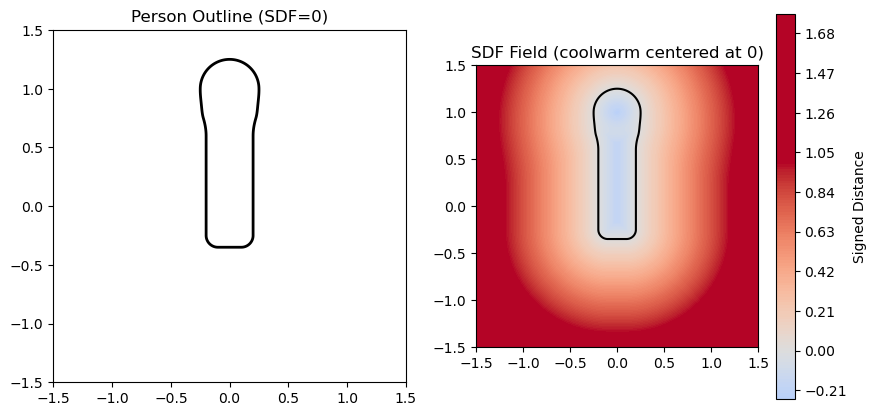

In [5]:
# %%
import numpy as np
import matplotlib.pyplot as plt

# --- Basic SDF Primitives ---

def sdf_circle(x, y, cx, cy, r):
    return np.sqrt((x - cx)**2 + (y - cy)**2) - r

def sdf_rounded_box(x, y, cx, cy, w, h, r):
    qx = np.abs(x - cx) - w
    qy = np.abs(y - cy) - h
    return np.sqrt(np.maximum(qx, 0)**2 + np.maximum(qy, 0)**2) + np.minimum(np.maximum(qx, qy), 0) - r

# --- SDF Combination: Smooth Union (fixed for arrays) ---
def smooth_union(d1, d2, k=0.3):
    h = np.clip(0.5 + 0.5 * (d2 - d1) / k, 0.0, 1.0)
    return (1 - h) * d2 + h * d1 - k * h * (1 - h)

# --- Build "Person" shape ---
def sdf_person(x, y):
    # Head
    d_head = sdf_circle(x, y, 0.0, 1.0, 0.25)
    # Body
    d_body = sdf_rounded_box(x, y, 0.0, 0.25, 0.1, 0.5, 0.1)
    # Arms
    d_left_arm  = sdf_rounded_box(x, y, -0.35, 0.25, 0.15, 0.1, 0.1)
    d_right_arm = sdf_rounded_box(x, y,  0.35, 0.25, 0.15, 0.1, 0.1)
    # Legs
    d_left_leg  = sdf_rounded_box(x, y, -0.15, -0.6, 0.1, 0.3, 0.1)
    d_right_leg = sdf_rounded_box(x, y,  0.15, -0.6, 0.1, 0.3, 0.1)

    # Combine parts smoothly
    d = d_head
    #for part in [d_body, d_left_arm, d_right_arm, d_left_leg, d_right_leg]:
    for part in [d_body]:
        d = smooth_union(d, part, k=0.2)
    return d

# --- Evaluate on grid ---
x = np.linspace(-1.5, 1.5, 400)
y = np.linspace(-1.5, 1.5, 400)
X, Y = np.meshgrid(x, y)
Z = sdf_person(X, Y)

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Left: person outline (zero level)
axes[0].contour(X, Y, Z, levels=[0], colors='black', linewidths=2)
axes[0].set_aspect('equal')
axes[0].set_title("Person Outline (SDF=0)")
axes[0].set_xlim(-1.5, 1.5)
axes[0].set_ylim(-1.5, 1.5)

# Right: full SDF field
c = axes[1].contourf(X, Y, Z, levels=200, cmap='coolwarm', vmin=-1, vmax=1)
axes[1].contour(X, Y, Z, levels=[0], colors='black', linewidths=1.5)
axes[1].set_aspect('equal')
axes[1].set_title("SDF Field (coolwarm centered at 0)")
fig.colorbar(c, ax=axes[1], label='Signed Distance')

plt.show()
